# scTOP Vignette 2- Constructing Reference Bases

In [1]:
# Load libraries
import pandas as pd
import plotly.io as pio
pio.renderers.default = 'notebook'
import sys
import os
os.chdir('/restricted/projectnb/crem-trainees/Kotton_Lab/Eitan/Vilker_Helper_Files/scTOP/vignettes') # Change to wherever your file is located
basisCollection = "../objects/BasisCollection.csv"  # Modify this file with your own basis names and file locations
datasetCollection = "../objects/DatasetCollection.csv"  # Modify this file with your own datasets and associated metadata
sys.path.append('../scripts')

# For if you want to edit the following libraries on the fly
%load_ext autoreload
%autoreload 1
%aimport SimilarityHelper
%aimport TopObject

## Load new dataset and set as basis

In [2]:
# We don't need to process the data if using it just as a basis, and processing is the slowest step
Habermann = TopObject.TopObject("Habermann", skipProcess=True)
Habermann.setBasis()

Setting AnnData object...
Setting AnnData...
Setting metadata and df...
Finished setup!
Setting basis...


100%|██████████| 11/11 [00:14<00:00,  1.32s/it]


Basis set!


celltype,Ciliated,AT2,SCGB3A2+,MUC5B+,Basal,SCGB3A2+ SCGB1A1+,Differentiating Ciliated,Transitional AT2,AT1,KRT5-/KRT17+,Proliferating Epithelial Cells
gene,,,,,,,,,,,
RP11-34P13.3,-0.005122,-0.004771,-0.005028,-0.004788,-0.005060,-0.004691,-0.005181,-0.004797,0.000028,-0.004691,-0.004689
FAM138A,-0.005122,-0.004771,-0.005028,-0.004788,-0.005060,-0.004691,-0.005181,-0.004797,-0.004338,-0.004691,-0.004689
OR4F5,-0.005122,-0.004771,-0.005028,-0.004788,-0.005060,-0.004691,-0.005181,-0.004797,-0.004338,-0.004691,-0.004689
RP11-34P13.7,-0.000944,-0.004771,-0.005028,-0.004788,-0.000903,-0.000304,-0.005181,-0.004797,-0.004338,-0.000464,-0.004689
RP11-34P13.8,-0.005122,-0.004771,-0.005028,-0.004788,-0.005060,-0.004691,-0.005181,-0.004797,-0.004338,-0.004691,-0.004689
...,...,...,...,...,...,...,...,...,...,...,...
AC233755.2,-0.000944,-0.004771,-0.005028,-0.004788,-0.005060,-0.004691,-0.005181,-0.004797,0.000292,-0.004691,-0.004689
AC233755.1,0.000210,-0.004771,0.000642,-0.004788,0.000474,-0.004691,-0.001071,-0.004797,-0.004338,0.000545,0.001617
AC240274.1,0.002796,0.002294,0.002315,0.002190,0.002716,0.002752,0.003009,0.002119,0.002272,0.002748,0.002494


## Test basis columns

In [7]:
# A good basis should have top1 accuracy > 80%
Habermann.testBasis(includeCriteria=Habermann.annotations.isin(Habermann.toKeep))

Trial: 1
Setting basis...


100%|██████████| 8/8 [00:04<00:00,  1.88it/s]


Basis set!
Processing test data...


100%|██████████| 10/10 [00:11<00:00,  1.19s/it]

top1: 0.7386787426744805
top3: 0.87773042088439
Unspecified: 0.0002663825253063399


{'top1': 2773, 'top3': 3295, 'Unspecified': 1, 'Total test count': 3754}

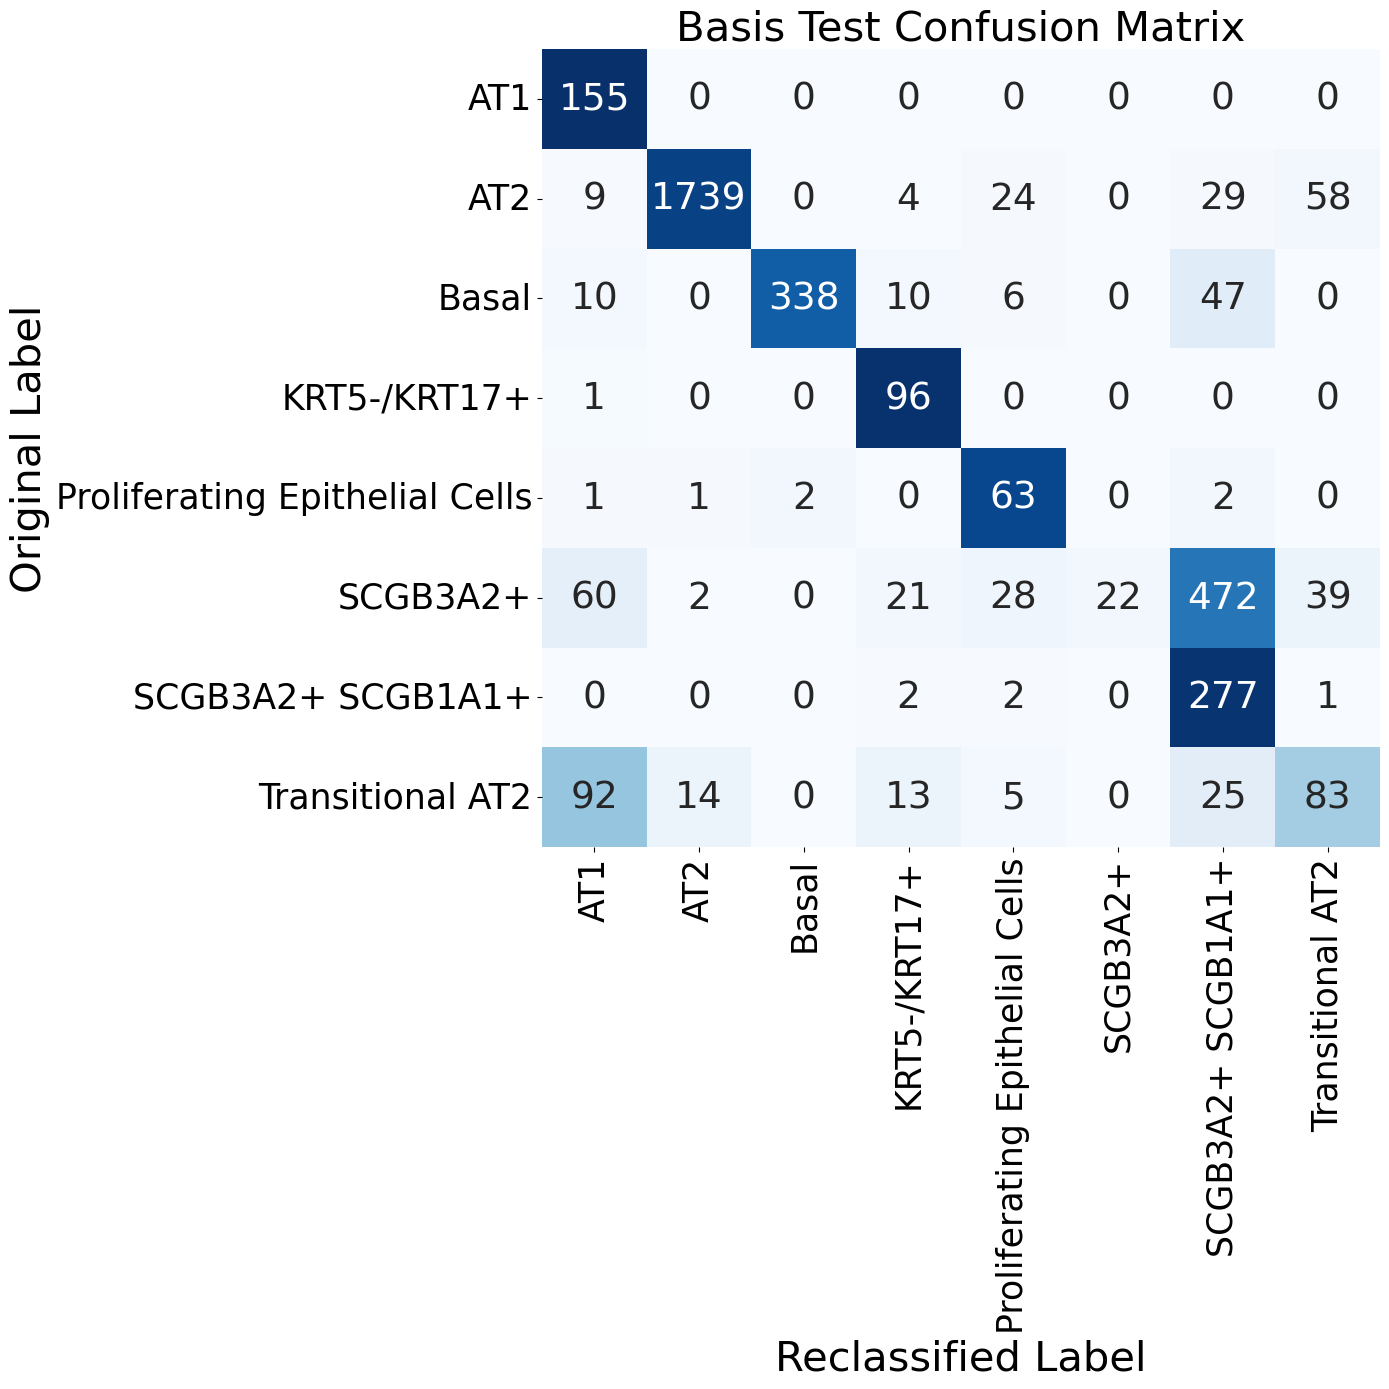

In [11]:
# You can also create a confusion matrix to see the distribution of what the test cells were predicted as
SimilarityHelper.plotBasisTestConfusionMatrix(Habermann, figX=14, figY=14)

In [13]:
# Based on these results, we can set the basis to include columns as is logical
Habermann.setBasis(includeCriteria=Habermann.annotations.isin(["KRT5-/KRT17+", "AT1", "AT2", "Basal", "SCGB3A2+ SCGB1A1+"]))

Setting basis...


100%|██████████| 5/5 [00:03<00:00,  1.47it/s]

Basis set!


celltype,AT2,Basal,SCGB3A2+ SCGB1A1+,AT1,KRT5-/KRT17+
gene,,,,,
RP11-34P13.3,-0.004771,-0.005060,-0.004691,0.000028,-0.004691
FAM138A,-0.004771,-0.005060,-0.004691,-0.004338,-0.004691
OR4F5,-0.004771,-0.005060,-0.004691,-0.004338,-0.004691
RP11-34P13.7,-0.004771,-0.000903,-0.000304,-0.004338,-0.000464
RP11-34P13.8,-0.004771,-0.005060,-0.004691,-0.004338,-0.004691
...,...,...,...,...,...
AC233755.2,-0.004771,-0.005060,-0.004691,0.000292,-0.004691
AC233755.1,-0.004771,0.000474,-0.004691,-0.004338,0.000545
AC240274.1,0.002294,0.002716,0.002752,0.002272,0.002748


## Load another dataset to test against this new basis

In [14]:
Ruwisch = TopObject.TopObject("Ruwisch") # Load object
Ruwisch.project(Habermann.basis, "Habermann") # Construct projections

Setting AnnData object...
Setting AnnData...
Setting metadata and df...
Processing scTOP data...
Done processing!
Finished setup!
Projecting onto basis...
Finished projecting! 17337 genes were in both the source and basis.


,AAACCAGGTCGAGGCAAGCTGTGA-1_10_1,AAACGGGCAAGCGATCAGCTGTGA-1_10_1,AAACGTTCAAAGCCTAAGCTGTGA-1_10_1,AAACGTTCAGGCTATAAGCTGTGA-1_10_1,AAACTGTCACAGCAACAGCTGTGA-1_10_1,AAAGATGCAATCGTGAAGCTGTGA-1_10_1,AAAGATGCACACTGGGAGCTGTGA-1_10_1,AAAGATGCACATAAACAGCTGTGA-1_10_1,AAAGCATGTAAGGTTGAGCTGTGA-1_10_1,AAAGCATGTGTTAGCTAGCTGTGA-1_10_1,...,TTGAGCGAGGGTTATAAGCTGTGA-1_60_1,TTGAGCGAGTGGCTTCAGCTGTGA-1_60_1,TTGATCAGTACTTAGCAGCTGTGA-1_60_1,TTGGTCATCCTTTGAGAGCTGTGA-1_60_1,TTGTACGTCGATATTCAGCTGTGA-1_60_1,TTGTACGTCGCTTGGTAGCTGTGA-1_60_1,TTGTCAGTCATAATCCAGCTGTGA-1_60_1,TTTAGTCAGATGCCTCAGCTGTGA-1_60_1,TTTGCGGGTGCTCCAAAGCTGTGA-1_60_1,TTTGCGGGTTCTCAAAAGCTGTGA-1_60_1
celltype,,,,,,,,,,,,,,,,,,,,,
AT2,0.094470,0.516084,-0.040838,0.008959,-0.167162,-0.016052,-0.058119,-0.159244,0.296414,0.412797,...,-0.008739,-0.038773,0.611702,-0.084588,-0.055578,0.076956,-0.042388,-0.061136,-0.111908,-0.096578
Basal,-0.119159,-0.221435,0.224183,-0.235041,-0.045389,-0.119188,-0.097708,-0.150074,-0.137929,-0.153895,...,-0.153109,0.030383,-0.159478,0.415726,0.016692,-0.047736,-0.035426,0.016233,0.538292,0.435389
SCGB3A2+ SCGB1A1+,0.172569,0.005712,-0.054595,0.012997,-0.029406,-0.076850,-0.043251,-0.050863,0.024673,-0.017898,...,-0.089505,0.231621,-0.058863,0.222115,0.200557,0.419378,0.159228,0.387593,-0.118409,-0.066507
AT1,0.178401,-0.040513,0.116492,0.425423,0.398703,0.407481,0.360327,0.543527,-0.004708,-0.055712,...,0.537680,-0.019445,0.101754,0.022849,0.026239,-0.005523,0.010589,-0.079994,0.066099,0.120892
KRT5-/KRT17+,-0.010660,0.016678,0.013428,0.068074,0.052197,0.044622,-0.000003,0.062247,-0.003864,0.004549,...,0.084213,0.009322,-0.061112,-0.018844,0.094191,-0.028745,0.118453,0.032890,0.107372,0.026540


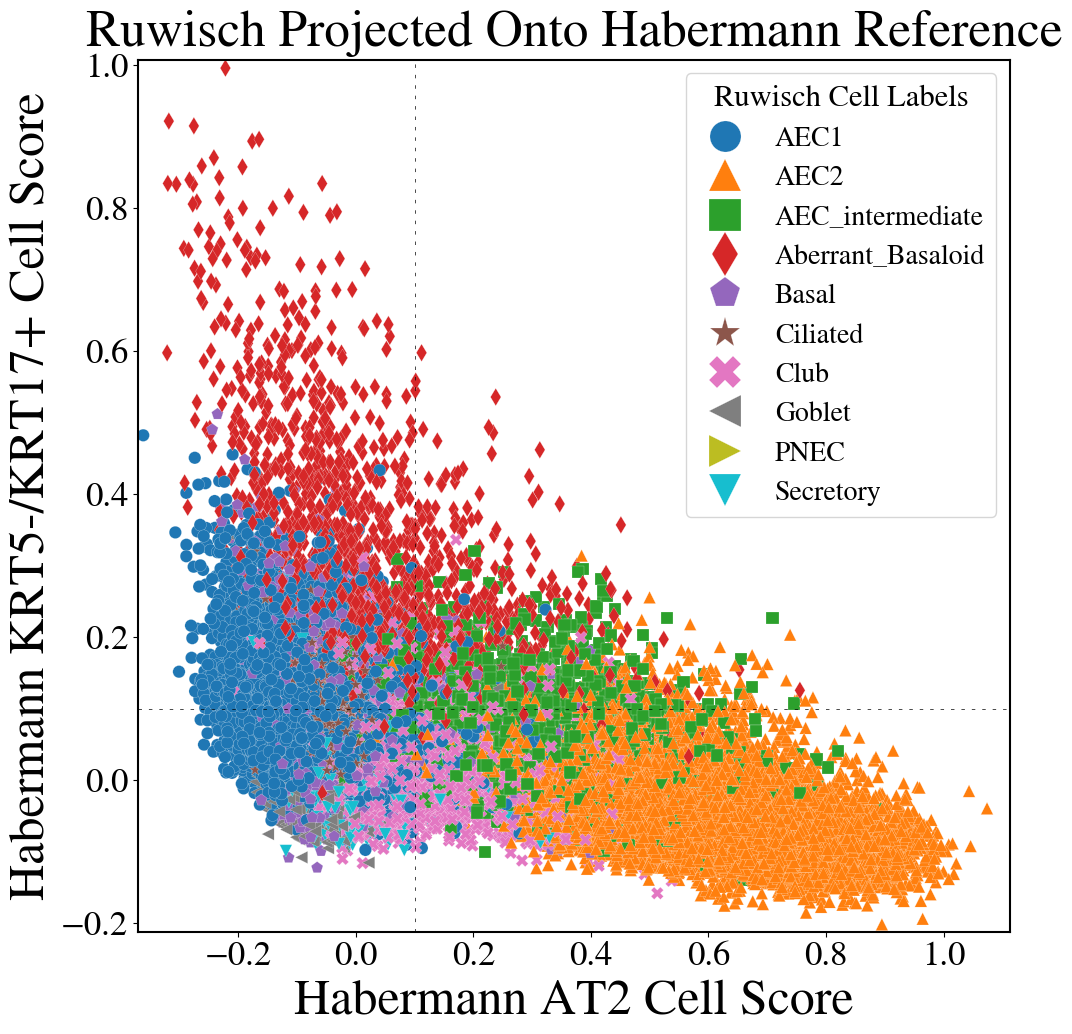

In [16]:
# Now plot exactly as before
ax = SimilarityHelper.plotTwo(Ruwisch, "Habermann", "AT2", "KRT5-/KRT17+")

## Combine two bases

In [22]:
# LungMAP will be our primary reference, and so we'll want to select specific labels from Ruwisch to add to it
humanBasis = TopObject.loadBasis(basisCollection=basisCollection, basisName="LungMAP")

# Combine Habermann's two selected cell types with all of LungMAP's
Habermann.combineBases(humanBasis, firstKeep=["SCGB3A2+ SCGB1A1+", "KRT5-/KRT17+"], name="LungMAP")

# Project test set onto the combined basis
Ruwisch.project(Habermann.combinedBases["LungMAP"], "LungMAP + Habermann")

Loaded LungMAP basis!
Combining bases...
Projecting onto basis...
Finished projecting! 17298 genes were in both the source and basis.


,AAACCAGGTCGAGGCAAGCTGTGA-1_10_1,AAACGGGCAAGCGATCAGCTGTGA-1_10_1,AAACGTTCAAAGCCTAAGCTGTGA-1_10_1,AAACGTTCAGGCTATAAGCTGTGA-1_10_1,AAACTGTCACAGCAACAGCTGTGA-1_10_1,AAAGATGCAATCGTGAAGCTGTGA-1_10_1,AAAGATGCACACTGGGAGCTGTGA-1_10_1,AAAGATGCACATAAACAGCTGTGA-1_10_1,AAAGCATGTAAGGTTGAGCTGTGA-1_10_1,AAAGCATGTGTTAGCTAGCTGTGA-1_10_1,...,TTGAGCGAGGGTTATAAGCTGTGA-1_60_1,TTGAGCGAGTGGCTTCAGCTGTGA-1_60_1,TTGATCAGTACTTAGCAGCTGTGA-1_60_1,TTGGTCATCCTTTGAGAGCTGTGA-1_60_1,TTGTACGTCGATATTCAGCTGTGA-1_60_1,TTGTACGTCGCTTGGTAGCTGTGA-1_60_1,TTGTCAGTCATAATCCAGCTGTGA-1_60_1,TTTAGTCAGATGCCTCAGCTGTGA-1_60_1,TTTGCGGGTGCTCCAAAGCTGTGA-1_60_1,TTTGCGGGTTCTCAAAAGCTGTGA-1_60_1
SCGB3A2+ SCGB1A1+,0.317101,0.157587,0.079071,0.164302,0.129916,0.108358,0.106733,0.088355,0.098897,0.087518,...,0.154987,0.114469,0.187507,0.174489,0.080984,0.165395,0.065925,0.144370,0.033726,0.095636
KRT5-/KRT17+,0.043887,0.112032,0.059330,0.138899,0.100508,0.113954,0.041286,0.103031,0.046690,0.061087,...,0.194503,0.000641,0.064811,-0.005824,0.055140,-0.046313,0.065547,0.026132,0.136885,0.053559
AT1,0.146920,-0.091612,0.127651,0.355922,0.378748,0.365097,0.351649,0.487982,-0.054654,-0.034904,...,0.412910,0.004104,0.023221,0.031063,-0.058484,0.011883,-0.014380,-0.110361,0.128999,0.182005
AT2,0.099016,0.457236,-0.045253,-0.028327,-0.178578,-0.034223,-0.104950,-0.160492,0.300446,0.315506,...,-0.014235,-0.112118,0.566694,-0.064052,-0.158865,0.022624,-0.174710,-0.124135,-0.126150,-0.124260
Basal,-0.116956,-0.258256,0.220641,-0.204113,0.020895,-0.117799,-0.066687,-0.089973,-0.130970,-0.194134,...,-0.136171,-0.175657,-0.193113,0.294720,-0.235533,-0.278521,-0.236148,-0.255334,0.607659,0.531855
Ciliated,-0.092345,-0.086114,-0.033792,-0.170935,-0.141905,-0.105600,-0.068694,-0.131478,-0.068981,-0.043665,...,-0.135894,0.115395,-0.103921,-0.015681,0.885700,-0.106265,0.816499,0.137342,-0.062438,-0.049495
Goblet,-0.032630,-0.025957,-0.082034,0.049906,-0.096533,-0.020693,-0.017550,0.032054,-0.049732,-0.014162,...,0.029219,0.274357,0.034407,0.213927,0.011544,0.467944,-0.049619,0.326666,-0.063615,-0.127606
Secretory,-0.056962,-0.005245,-0.063029,-0.029507,-0.005111,-0.066428,-0.073837,-0.073126,0.023643,0.005583,...,-0.134666,0.007935,-0.151582,-0.052029,-0.218178,0.189259,-0.188804,0.165691,-0.161791,-0.128683


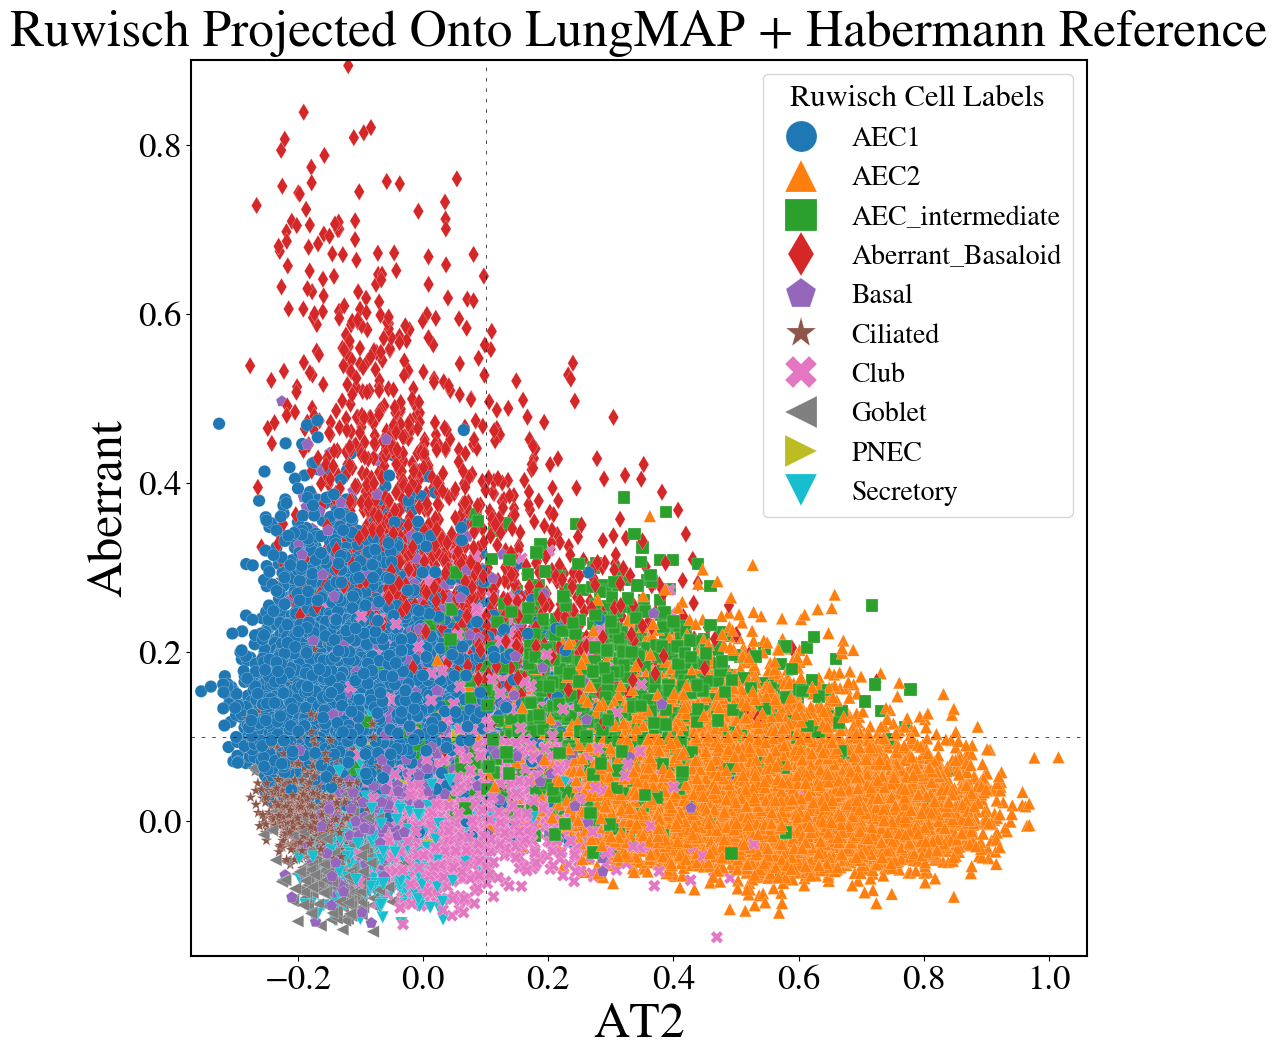

In [25]:
# Now plot against the same axes, but with the hopefully more informed background information provided by Natri (axes can be in any combination from the bases)
ax = SimilarityHelper.plotTwo(Ruwisch, "LungMAP + Habermann", "AT2", "KRT5-/KRT17+", axisRenames=("AT2", "Aberrant"))